## The State of Tax Justice: Impute Missing Data
- Author: Alison Schultz, based on Javier Garcia Bernado's work
- Created: 20 August 2023
- Last updated: 11 August 2024

**Description**
- This notebook is one out of three notebooks to estimate the tax losses caused by profit shifting by multinational enterprises (MNEs). The analysis used the misalignment method based on the country-by-country reports (CbCR) published by the OECD.
- This notebook uses the extended CBCR dataset "data/intermediate/cbcr_imputation_sample.csv" created in the notebook "1_clean" and imputes missing values, resulting in the notebook "data/final/cbcr_main.csv". It also generates all descriptives used to assess the imputation success.

**Outline**
1. 

**To dos before running this notebook**
1.

In [4]:
import pandas as pd
import numpy as np
from config import *
import tjn_tools
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from itertools import permutations, product
from sklearn.metrics import r2_score,make_scorer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LassoCV, Lasso, LinearRegression, BayesianRidge
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import cross_validate, train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.inspection import permutation_importance

## 3. Imputate missing values

### 3.1 Import and define relevant datasets

In [5]:
cbcr_imputation_sample = pd.read_csv(f'{data_intermediate}/cbcr_imputation_sample.csv')
cbcr_main_no_imputation_allsubgroupsonly = pd.read_csv(f'{data_intermediate}/cbcr_main_no_imputation_allsubgroupsonly.csv')

In [6]:
# For the domestic imputation, we only use variables that are not bilateral in nature
# PAPER JAVIER: However, the information on domestic activities of MNCs is important, especially for large countries. This is addressed by estimating the number of domestic
# employees, revenue and tangible assets for all non-reporting countries. We do so by using a linear
# model based on the number of expected companies in each country, its GDP, population, the average
# ETRs and the total consolidated banking claims on an immediate counterparty basis

domestic_variables = [
    'iso_parent',
    'iso_partner', # this is always the same as iso_parent, but easier to keep here for following maxing exercises
    'year',
    "income_tax_paid_on_cash_basis",
    "ln_income_tax_paid_on_cash_basis",
    "ln_profit_loss_before_income_tax_corrected",
    "ln_n_employees",
    "ln_unrelated_party_revenues",
    "ln_tangible_assets_except_cash",
    'ln_stated_capital',
    'ln_total_revenues',
    'ln_related_party_revenues',
    'ln_holding_or_managing_ip',
    "etr_foreign_corrected", # I only use foreign here, because countries with missing domestic data will not have domestic ETRs and we do not want to impute them either
    "cit",
    'ln_wage_monthly',
    'ln_gdp_current_usd',
    'ln_population',
    'ln_gvt_health_expenditure',
    'ln_n_companies_orbis',
    'ln_turnover_orbis',
    'ln_n_employees_orbis',
    'region_tjn',
    'ukt'
]
domestic_imputation_sample = cbcr_imputation_sample.loc[cbcr_imputation_sample["iso_parent"] == cbcr_imputation_sample["iso_partner"], domestic_variables]
domestic_imputation_sample = domestic_imputation_sample.copy()
domestic_imputation_sample.replace([np.inf, -np.inf], np.nan, inplace=True)
foreign_imputation_sample = cbcr_imputation_sample.loc[cbcr_imputation_sample["iso_parent"] != cbcr_imputation_sample["iso_partner"]]
foreign_imputation_sample = foreign_imputation_sample.copy()
foreign_imputation_sample.replace([np.inf, -np.inf], np.nan, inplace=True) 
true_values = cbcr_main_no_imputation_allsubgroupsonly[["iso_parent","iso_partner","year",'income_tax_paid_on_cash_basis','profit_loss_before_income_tax_corrected',
'n_employees',"unrelated_party_revenues","tangible_assets_except_cash",'stated_capital','total_revenues','related_party_revenues','holding_or_managing_ip']]

### 3.2 Impute values

#### 3.2.1 Define metaparameters for imputation

In [7]:
# DEFINE SCORER TO VALIDATE AND COMPARE MODELS
scorer = make_scorer(r2_score)

In [8]:
# For documentation purposes only: This is how the metaestimators were determined
if 0:
    def find_best_model(est,clf,df):
        
        for var in ["ln_profit_loss_before_income_tax_corrected",
        "ln_n_employees",
        "ln_unrelated_party_revenues",
        "ln_tangible_assets_except_cash",
        'ln_stated_capital',
        'ln_total_revenues',
        'ln_related_party_revenues',
        'ln_holding_or_managing_ip']:
            df = cbcr_main_no_imputation_allsubgroupsonly.copy().dropna(subset=["ln_profit_loss_before_income_tax_corrected",var])
            df[var].replace([np.inf, -np.inf], np.nan, inplace=True)
            print(var)
            y = df[var].values
            a = df.drop(columns=["income_tax_paid_on_cash_basis","ln_profit_loss_before_income_tax_corrected","ln_n_employees","ln_unrelated_party_revenues",
                "ln_tangible_assets_except_cash",'ln_stated_capital','ln_total_revenues','ln_related_party_revenues','ln_holding_or_managing_ip']
                +[_ for _ in df.columns if "fitted" in _]+[_ for _ in df.columns if "month_wage" in _])
            columns = np.array(a.columns)[a.dtypes!=object]
    #         print(columns)
            X = df[columns].values
    #         display(df[columns].describe())
            print(y.min(),y.mean(),y.max(),y.std())


            search = clf.fit(X,y)
            print(var, search.best_params_)
            try:
                plt.plot(search.param_grid["alpha"],search.cv_results_["mean_test_score"])
                plt.show()
            except:
                pass            

In [9]:
# Estimate metaparameters
if 0: # For documentation purposes only: This is how the metaestimators were determined
    distributions = dict(learning_rate=np.linspace(0.01,0.2,7),
                            l2_regularization=np.logspace(1,3,11),
                            min_samples_leaf=[20],)
    est = HistGradientBoostingRegressor(random_state=0)

    clf = GridSearchCV(est, distributions, n_jobs=-1, cv=5,verbose=5, scoring=scorer)

    find_best_model(est,clf,foreign_imputation_sample.dropna(subset=["ln_profit_loss_before_income_tax_corrected"]))

In [10]:
# Set identified parameters
metaparameters  = {
    "ln_profit_loss_before_income_tax_corrected": {'l2_regularization': 25.118864315095795, 'learning_rate': 0.105, 'min_samples_leaf': 20},
    "ln_n_employees": {'l2_regularization': 10.0, 'learning_rate': 0.1366666666666667, 'min_samples_leaf': 20},
    "ln_unrelated_party_revenues": {'l2_regularization': 10.0, 'learning_rate': 0.105, 'min_samples_leaf': 20},
    "ln_tangible_assets_except_cash": {'l2_regularization': 15.848931924611133, 'learning_rate': 0.07333333333333333, 'min_samples_leaf': 20}, # We take the metaparameters from ln_stated_capital as they are not estimated for ln_tangible_assets_except_cash
    'ln_stated_capital': {'l2_regularization': 15.848931924611133, 'learning_rate': 0.07333333333333333, 'min_samples_leaf': 20},
    'ln_total_revenues': {'l2_regularization': 39.810717055349734, 'learning_rate': 0.2, 'min_samples_leaf': 20},
    'ln_related_party_revenues': {'l2_regularization': 10.0, 'learning_rate': 0.07333333333333333, 'min_samples_leaf': 20},
    'ln_holding_or_managing_ip': {'l2_regularization': 10.0, 'learning_rate': 0.105, 'min_samples_leaf': 20},
}

#### 3.2.2 Define imputation function

In [11]:
# DEFINE IMPUTING FUNCTION BASED ON BAYESIAN RIDGE
def impute(imputation_sample,columns_used_for_imputation,verbose=0):
    '''Imputes the variables specified by "columns" based on the data given in the "imputation_sample" (which also needs to include the variables specified in "columns")
      by BayesianRidge (which performs quite as well as missForest (R))'''
    imputation_sample = imputation_sample[imputation_sample['year'].between(first_year, first_year+n_years-1)] 
    imputation_sample = imputation_sample.dropna(axis=1, how='all')
    imputation_sample = imputation_sample.dropna(axis=0, how='all')
    
    values = imputation_sample[columns_used_for_imputation].values
    print(values.shape)
    estimator = BayesianRidge()                                                     #(n_estimators=10, random_state=0, bootstrap=True, n_jobs=-1)
    imp = IterativeImputer(max_iter=100, estimator = estimator,verbose=verbose) 
    imp.fit(values)
    new_values = imp.transform(values)
    print(new_values.shape)

    #Replace with full info
    for i,col in enumerate(columns_used_for_imputation):
        imputation_sample[col] = new_values[:, i]
    
    return imputation_sample

#### 3.2.3 Define imputation procedure for domestic values

In [12]:
def fill_domestic(domestic_imputation_sample, bootstrap=False, output=False, columns=None):
    dfs = []  # list to store regression coefficient dataframes (if output=True)

    for var in ['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', "ln_unrelated_party_revenues",
                "ln_tangible_assets_except_cash", 'ln_stated_capital', 'ln_total_revenues', 
                'ln_related_party_revenues', 'ln_holding_or_managing_ip']:

        # Initialize a linear regression model
        clf = LinearRegression()
        # Filter data based on the year range
        df = domestic_imputation_sample[domestic_imputation_sample['year'].between(first_year, first_year + n_years - 1)].copy()
        # Filter rows that have non-missing values for the current variable
        df = df.dropna(subset=[var])
        # Use default columns if none provided
        if columns is None:
            columns = ["ln_gdp_current_usd", "ln_population", "ln_gvt_health_expenditure", "etr_foreign_corrected", 
                       "cit", "ln_n_companies_orbis", "ln_turnover_orbis", "ln_n_employees_orbis", 'ln_wage_monthly']

        # Bootstrap the data if specified
        if bootstrap:
            df = df[df["ln_n_companies_orbis"] > 0].sample(frac=1, replace=True).copy()

        # Get predictor variables and target variable
        X = df[df["ln_n_companies_orbis"] > 0][columns]  # Keep X as DataFrame
        y = df[df["ln_n_companies_orbis"] > 0][var].values

        if X.shape[0] == 0:
            print(f"No samples available for training {var}. Skipping...")
            continue

        # Train the model
        clf.fit(X, y)

        # Print R-squared values if output flag is set to True
        if output:
            print(var, r2_score(y, clf.predict(X)))
            coeff_df = pd.DataFrame({'Variable': columns, 'Coefficient': clf.coef_})
            dfs.append(coeff_df.set_index('Variable'))

        # Make predictions and store them in the dataframe
        domestic_imputation_sample[f"fitted_{var}"] = clf.predict(domestic_imputation_sample[columns])

        # Special treatment for rows where "ln_n_companies_orbis" is 0
        domestic_imputation_sample.loc[domestic_imputation_sample["ln_n_companies_orbis"] == 0, f"fitted_{var}"] = 0

        # Convert predictions from logarithmic scale to linear scale
        domestic_imputation_sample[var[3:]] = np.exp(domestic_imputation_sample[f"fitted_{var}"]) - 1

    # Set the 'iso_partner' column equal to the 'iso_parent' column
    domestic_imputation_sample["iso_partner"] = domestic_imputation_sample["iso_parent"]

    # Display the regression coefficients if output flag is set to True
    if output:
        display(pd.concat(dfs, axis=1))

    return domestic_imputation_sample

In [13]:
# To illustrate domestic imputation --> to figures notebook
variables_used_for_domestic_imputation = np.array(domestic_imputation_sample.columns)[domestic_imputation_sample.dtypes!=object]
variables_used_for_domestic_imputation = [_ for _ in variables_used_for_domestic_imputation if (_ not in true_values.columns) and (_[3:] not in true_values.columns)]
print(variables_used_for_domestic_imputation)
# ['etr_foreign_corrected', 'cit', 'ln_wage_monthly', 'ln_gdp_current_usd', 'ln_population', 'ln_gvt_health_expenditure', 'ln_n_companies_orbis', 'ln_turnover_orbis', 'ln_n_employees_orbis', 'g7', 'g20', 'eu27', 'ukt']
domestic_values_imputed = impute(domestic_imputation_sample,variables_used_for_domestic_imputation,verbose=5)
cbcr_with_imputed_domestic_values = fill_domestic(domestic_values_imputed,bootstrap=False,output=True,
                  columns =["ln_gdp_current_usd","ln_population","etr_foreign_corrected","ln_n_companies_orbis"])

['etr_foreign_corrected', 'cit', 'ln_wage_monthly', 'ln_gdp_current_usd', 'ln_population', 'ln_gvt_health_expenditure', 'ln_n_companies_orbis', 'ln_turnover_orbis', 'ln_n_employees_orbis', 'ukt']
(390, 10)
[IterativeImputer] Completing matrix with shape (390, 10)
[IterativeImputer] Ending imputation round 1/100, elapsed time 0.07
[IterativeImputer] Change: 6.287741907314634, scaled tolerance: 0.030792014872240744 
[IterativeImputer] Ending imputation round 2/100, elapsed time 0.09
[IterativeImputer] Change: 2.1712623791348253, scaled tolerance: 0.030792014872240744 
[IterativeImputer] Ending imputation round 3/100, elapsed time 0.17
[IterativeImputer] Change: 2.4351526001778687, scaled tolerance: 0.030792014872240744 
[IterativeImputer] Ending imputation round 4/100, elapsed time 0.18
[IterativeImputer] Change: 2.203356067753189, scaled tolerance: 0.030792014872240744 
[IterativeImputer] Ending imputation round 5/100, elapsed time 0.21
[IterativeImputer] Change: 1.9942596204474823, sca

c:\Users\AlisonSchultz\anaconda3\envs\sotj_profit_shifting_estimates\Lib\site-packages\sklearn\impute\_iterative.py:796: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient
Variable,,,,,,,,
ln_gdp_current_usd,1.315386,0.953172,0.726754,0.527387,0.457121,0.782790,1.354087,1.058718
ln_population,0.400499,0.196614,-0.060822,0.203704,-0.009601,-0.103527,-0.356790,-0.558000
etr_foreign_corrected,2.474149,0.981676,1.847820,0.686493,-2.303549,0.913852,-0.532269,0.228733
ln_n_companies_orbis,0.141550,0.205747,0.649690,0.503787,0.860374,0.620612,0.375852,0.626889


### 3.2.4 Define imputation procedure for foreign values

In [14]:
def fill_foreign(foreign_imputation_sample, bootstrap=False, output=False, n_repeats=2):
    i = 0
    if output:
        fig = plt.figure(figsize=(18, 12))
    
    # Iterate over the specified variables
    for var in ['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', "ln_unrelated_party_revenues", 
                "ln_tangible_assets_except_cash", 'ln_stated_capital', 'ln_total_revenues', 
                'ln_related_party_revenues', 'ln_holding_or_managing_ip']:
        i += 1
        print(metaparameters.keys())
        # Initialize the model with the metaparameters
        clf = HistGradientBoostingRegressor(**metaparameters[var])
        
        # Filter the data for the year range
        foreign_imputation_sample = foreign_imputation_sample[foreign_imputation_sample['year'].between(first_year, first_year + n_years - 1)].copy()

        # Drop rows with missing values for the current variable
        df = foreign_imputation_sample.dropna(subset=[var]).copy()
        
        # Select the predictor columns excluding the specified ones and those containing "fitted" or "wage_monthly"
        a = df.drop(columns=["income_tax_paid_on_cash_basis", 'ln_profit_loss_before_income_tax_corrected', 'ln_n_employees',
                             "ln_unrelated_party_revenues", "ln_tangible_assets_except_cash", 'ln_stated_capital', 
                             'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip']
                             + [_ for _ in df.columns if "fitted" in _] 
                             + [_ for _ in df.columns if "wage_monthly" in _])
        
        # Get predictor column names where data types are not object
        columns = np.array(a.columns)[a.dtypes != object]

        # Bootstrap the data if specified
        if bootstrap:
            df = df.sample(frac=1, replace=True).copy()

        # Get predictor variables (X) and target variable (y)
        X = df[columns]  # Keep X as a pandas DataFrame to retain feature names
        y = df[var].values

        # Fit the model
        clf.fit(X, y)
        
        # Make predictions and store them in the dataframe
        foreign_imputation_sample[f"fitted_{var}"] = clf.predict(foreign_imputation_sample[columns])

        if output:
            try:
                # Print the coefficients, if available
                print([_ for _ in sorted(zip(clf.coef_, columns)) if _[0] != 0])
            except AttributeError:
                pass

            # Perform permutation importance and visualize
            result = permutation_importance(clf, X.values, y, n_repeats=n_repeats,
                                            random_state=42, n_jobs=1, scoring=scorer)
            sorted_idx = result.importances_mean.argsort()

            plt.subplot(1, 3, i)
            sorted_idx = result.importances_mean.argsort()
            vals = 40
            labels = columns[sorted_idx][-vals:]
            labels = [_[-20:] for _ in labels]  # Cut if too long
            plt.boxplot(100 * result.importances[sorted_idx].T[:, -vals:],
                        vert=False, labels=labels)
            plt.xlabel("Decrease in R2 (% points)")
            plt.title(f"{var}")
            sns.despine(bottom=True, left=True)
            plt.xscale("log")

    if output:
        plt.tight_layout()
        plt.savefig(f"{output_figures}/permutation_estimation.pdf", bbox_inches="tight")
        plt.show()
    
    return foreign_imputation_sample

In [15]:
# Illustrate imputation of foreign values --> to figures notebook
cbcr_plus_imputed_foreign_values = fill_foreign(foreign_imputation_sample,bootstrap=False,output=False)

dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])


c:\Users\AlisonSchultz\anaconda3\envs\sotj_profit_shifting_estimates\Lib\site-packages\joblib\externals\loky\backend\context.py:150: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\AlisonSchultz\anaconda3\envs\sotj_profit_shifting_estimates\Lib\site-packages\joblib\externals\loky\backend\context.py", line 245, in _count_physical_cores
    raise ValueError(


dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_in

#### 3.2.5 Substitute imputed with correct values whenever we do have correct values

In [16]:
# To illustrate substitution of missing values
# Substitute imputed with correct values whenever we do not have correct values
for var in ['ln_profit_loss_before_income_tax_corrected','ln_n_employees',"ln_unrelated_party_revenues","ln_tangible_assets_except_cash",
  'ln_stated_capital','ln_total_revenues','ln_related_party_revenues','ln_holding_or_managing_ip']:
    cbcr_with_imputed_foreign_values_countrygroups = cbcr_plus_imputed_foreign_values.copy()
    cbcr_with_imputed_foreign_values_countrygroups.loc[~np.isnan(cbcr_with_imputed_foreign_values_countrygroups[var]),"fitted_"+var
                                         ] = cbcr_with_imputed_foreign_values_countrygroups.loc[~np.isnan(cbcr_with_imputed_foreign_values_countrygroups[var]),var] 
    cbcr_with_imputed_domestic_values.loc[~np.isnan(cbcr_with_imputed_domestic_values[var]),"fitted_"+var
                                          ] = cbcr_with_imputed_domestic_values.loc[~np.isnan(cbcr_with_imputed_domestic_values[var]),var] 
  
    cbcr_with_imputed_domestic_values.loc[(cbcr_with_imputed_domestic_values["ln_n_companies_orbis"]==0),"fitted_"+var] = 0
    cbcr_with_imputed_foreign_values_countrygroups.loc[cbcr_with_imputed_foreign_values_countrygroups["ln_n_companies_orbis"]==0,"fitted_"+var] = 0

### 3.3 Define how values of country groups should be assigned to individual countries

In [17]:
OAF = AFRIC = set(
    cbcr_main_no_imputation_allsubgroupsonly.loc[cbcr_main_no_imputation_allsubgroupsonly["region_tjn"] == "Africa", "iso_partner"].dropna()
    )
OAS = ASIAT = set(
    cbcr_main_no_imputation_allsubgroupsonly.loc[cbcr_main_no_imputation_allsubgroupsonly["region_tjn"] == "Asia", "iso_partner"].dropna()
    )
OTE = EUROP = set(
    cbcr_main_no_imputation_allsubgroupsonly.loc[cbcr_main_no_imputation_allsubgroupsonly["region_tjn"] == "Europe", "iso_partner"].dropna()
    )
OAM = LAC_sca = set(
    cbcr_main_no_imputation_allsubgroupsonly.loc[cbcr_main_no_imputation_allsubgroupsonly["region_tjn"].str.contains("America", na=False), "iso_partner"].dropna()
)
GRPS = set(cbcr_main_no_imputation_allsubgroupsonly["iso_partner"].dropna())
LAC = set(
    cbcr_main_no_imputation_allsubgroupsonly.loc[cbcr_main_no_imputation_allsubgroupsonly["region_tjn"] == "Latin America and the Caribbean", "iso_partner"].dropna()
    )

d_groups2countries = {"OAF": OAF, "AFRIC": AFRIC, "OAS": OAS, "ASIAT": ASIAT, "OTE": OTE, "EUROP": EUROP, "OAM": OAM, "LAC_sca": LAC_sca, "GRPS": GRPS, "LAC": LAC}

In [18]:
# function to adjust the total of country groups to a known total
def adjust_total(country, data, year):
    '''Adjust the total of country groups to a known total for a given year'''
    data = data[data['year'] == year]
    data = pd.DataFrame(data)
    
    agg_data = true_values.loc[(true_values["iso_parent"] == country) & (true_values["year"] == year)].copy()
    
    if len(agg_data) == 0:
        return data
    
    if country in ["AUT","SWE","NOR"]:
        agg_data["iso_partner"] = agg_data["iso_partner"].replace("LAC","LAC_sca")
    agg_data = agg_data.set_index("iso_partner")
    

    cs_included = list(agg_data.index)
    for region in ["OAF","OAM","OAS","OTE","AFRIC","ASIAT","EUROP","LAC","LAC_sca","FJT","GRPS"]:
        if region in agg_data.index:
            
            if region == "GRPS":
                cs_group = d_groups2countries[region] - set(cs_included)
                truth_remove = 0
            elif (region == "FJT"): 
                if ("GRPS" in agg_data.index):
                    continue #otherwise fix it with GRPS
                #Countries in the main df but not in the original one and not fixed before = FJT
                cs_group = set(data["iso_partner"])- set(cs_included)
#                 print(cs_group)
                #Remove from FJT everything fixed before
                truth_remove = agg_data.loc[list(set(agg_data.index) - set(["FJT",country])),
                ['profit_loss_before_income_tax_corrected','n_employees',"unrelated_party_revenues","tangible_assets_except_cash",
                'stated_capital','total_revenues','related_party_revenues','holding_or_managing_ip']].sum().fillna(0)

            else:
                cs_included += list(d_groups2countries[region])
                cs_group = d_groups2countries[region] - set(agg_data.index)
                truth_remove = 0

            truth = agg_data.loc[region,[
                'profit_loss_before_income_tax_corrected','n_employees',
                "unrelated_party_revenues","tangible_assets_except_cash",
                'stated_capital','total_revenues','related_party_revenues',
                'holding_or_managing_ip']] - truth_remove
            if isinstance(truth, pd.DataFrame):
                truth = truth.sum()
    
            pred = np.exp(data.loc[data["iso_partner"].isin(cs_group),[
                'fitted_ln_profit_loss_before_income_tax_corrected','fitted_ln_n_employees',
                "fitted_ln_unrelated_party_revenues","fitted_ln_tangible_assets_except_cash",
                'fitted_ln_stated_capital','fitted_ln_total_revenues','fitted_ln_related_party_revenues',
                'fitted_ln_holding_or_managing_ip']])-1
            
            #If profits are negative in the region set them up to 0
            scale_by = pred.sum().values/truth.values
            scale_by[truth.values<0] = np.inf
            
            aux = 1+pred/scale_by
            data.loc[data["iso_partner"].isin(cs_group),
            ['fitted_ln_profit_loss_before_income_tax_corrected','fitted_ln_n_employees',
            "fitted_ln_unrelated_party_revenues","fitted_ln_tangible_assets_except_cash",
            'fitted_ln_stated_capital','fitted_ln_total_revenues','fitted_ln_related_party_revenues',
            'fitted_ln_holding_or_managing_ip']] = np.log(aux.apply(pd.to_numeric))

        else: #Countries where no operations
            if region == "GRPS":
                cs_group = d_groups2countries[region] - set(cs_included)
                
                data.loc[data["iso_partner"].isin(cs_group),
                ['fitted_ln_profit_loss_before_income_tax_corrected','fitted_ln_n_employees',"fitted_ln_unrelated_party_revenues","fitted_ln_tangible_assets_except_cash",
                    'fitted_ln_stated_capital','fitted_ln_total_revenues','fitted_ln_related_party_revenues','fitted_ln_holding_or_managing_ip']] = 0
                                
    return data

In [19]:
# To illustrate final datasets
cbcr_with_imputed_foreign_values_grouped = [
    adjust_total(country, group_data, year) 
    for (country, year), group_data in cbcr_with_imputed_foreign_values_countrygroups.groupby(["iso_parent", "year"])
]
cbcr_with_imputed_foreign_values = pd.concat(cbcr_with_imputed_foreign_values_grouped)

for var in ['ln_profit_loss_before_income_tax_corrected','ln_n_employees',"ln_unrelated_party_revenues","ln_tangible_assets_except_cash"]:
    cbcr_with_imputed_foreign_values.loc[:,var[3:]] = np.exp(cbcr_with_imputed_foreign_values["fitted_" + var])-1
    cbcr_with_imputed_domestic_values.loc[:,var[3:]] = np.exp(cbcr_with_imputed_domestic_values["fitted_" + var])-1

### 3.4 Check validity of imputation procedure

(10000000.0, 2000000000000.0)

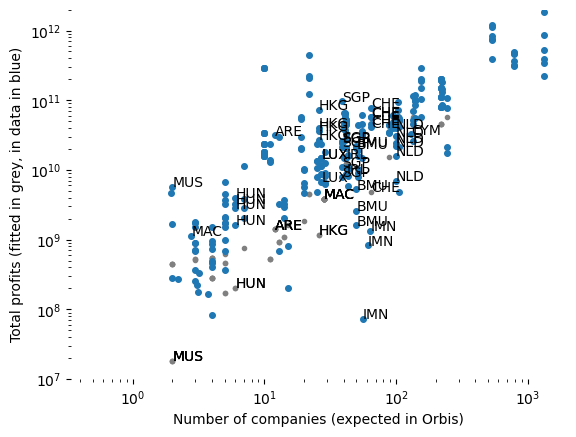

In [20]:
# DOMESTIC RESULTS
for c,x,y in zip(cbcr_with_imputed_domestic_values["iso_parent"],np.exp(cbcr_with_imputed_domestic_values["ln_n_companies_orbis"]),np.exp(cbcr_with_imputed_domestic_values["fitted_ln_profit_loss_before_income_tax_corrected"])):
    if c in tax_havens:
        plt.annotate(c,(x,y))
plt.plot(np.exp(cbcr_with_imputed_domestic_values["ln_n_companies_orbis"]),np.exp(cbcr_with_imputed_domestic_values["fitted_ln_profit_loss_before_income_tax_corrected"]),".",color="grey")
plt.plot(np.exp(cbcr_with_imputed_domestic_values["ln_n_companies_orbis"]),np.exp(cbcr_with_imputed_domestic_values["ln_profit_loss_before_income_tax_corrected"]),".",ms=8)
plt.xscale("log")
plt.yscale("log")
sns.despine(bottom=True,left=True)
plt.xlabel("Number of companies (expected in Orbis)")
plt.ylabel("Total profits (fitted in grey, in data in blue)")
plt.ylim(1E7,2E12)

In [21]:
# Function to check how well our imputation works
def plot_matching_foreign(true_values,foreign_imputation_sample,annot=False):
    #What we get vs what we know
    #x_fjt = true_values.loc[true_values["iso3_d"]=="FJT"].groupby("iso3_o").agg(lambda x: np.sum(x[x>0]))
    numeric_cols = true_values.select_dtypes(include=np.number).columns
    x_fjt = true_values.loc[true_values["iso_partner"] == "FJT"].groupby("iso_parent")[numeric_cols].agg(lambda x: np.sum(x[x > 0]))
    x_other = true_values.loc[
        (true_values["iso_parent"] != true_values["iso_partner"])
        & (~true_values["iso_parent"].isin(x_fjt.index))
        ].groupby("iso_parent")[numeric_cols].agg(lambda x: np.sum(x[x > 0]))
    x = pd.concat([x_fjt,x_other])
    a = foreign_imputation_sample.groupby("iso_parent")["fitted_ln_profit_loss_before_income_tax_corrected"].agg(lambda x: np.sum(np.exp(x[x>0]))).to_dict()
    x["a"] = x.index.map(a)
    plt.plot(x["profit_loss_before_income_tax_corrected"],x["a"],"o")
    plt.plot([1E8,1E12],[1E8,1E12],"--",color="grey")
    plt.xscale("log")
    plt.yscale("log")
    if annot:
        for x_,y_,c_ in zip(x["profit_loss_before_income_tax_corrected"],x["a"],x.index):
            if (x_>0) and (y_>0): 
                plt.annotate(c_,(x_,y_))

    plt.xlabel("Real foreign profits")
    plt.ylabel("Predicted foreign profits")
    sns.despine(bottom=True,left=True)
    plt.show()

Predictions for NLDs


c:\Users\AlisonSchultz\anaconda3\envs\sotj_profit_shifting_estimates\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\AlisonSchultz\AppData\Local\Temp\ipykernel_18136\1959275797.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ground["ln_"+var] = np.log(1+ground[var])
C:\Users\AlisonSchultz\AppData\Local\Temp\ipykernel_18136\1959275797.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ground["l

,iso_parent,iso_partner,year,income_tax_paid_on_cash_basis,profit_loss_before_income_tax_corrected,n_employees,unrelated_party_revenues,tangible_assets_except_cash,stated_capital,total_revenues,related_party_revenues,holding_or_managing_ip,ln_profit_loss_before_income_tax_corrected,ln_n_employees,ln_unrelated_party_revenues,ln_tangible_assets_except_cash,ln_stated_capital,ln_total_revenues,ln_related_party_revenues,ln_holding_or_managing_ip
11404,NLD,A_O,2020,1.556068e+09,-9.168524e+09,734638.0,3.496210e+11,2.038210e+11,5.448120e+11,5.490670e+11,1.994470e+11,172.0,NaN,13.507135,26.580116,26.040508,27.023707,27.031486,26.018814,5.153292
11405,NLD,A_O,2021,4.468567e+09,2.567701e+10,562641.0,2.840000e+11,9.712838e+10,2.760000e+11,4.010000e+11,1.160000e+11,254.0,23.968862,13.240399,26.372240,25.299299,26.343667,26.717227,25.476856,5.541264
11406,NLD,BEL,2018,4.441961e+08,3.892996e+09,115241.0,3.686851e+10,9.792941e+09,2.550636e+10,4.796009e+10,1.112434e+10,13.0,22.082445,11.654790,24.330624,23.004928,23.962194,24.593635,23.132402,2.639057
11407,NLD,BEL,2019,5.281736e+08,3.285688e+09,112389.0,3.066730e+10,9.174097e+09,1.648193e+10,3.892039e+10,8.253090e+09,12.0,21.912842,11.629730,24.146463,22.939650,23.525531,24.384784,22.833853,2.564949
11408,NLD,BEL,2020,3.119184e+08,1.376079e+09,102172.0,2.950668e+10,8.907291e+09,1.752810e+10,4.527525e+10,7.766938e+09,14.0,21.042504,11.534423,24.107882,22.910136,23.587071,24.536026,22.773142,2.708050
11409,NLD,BEL,2021,4.656086e+08,2.067075e+09,99648.0,2.570140e+10,7.592746e+09,1.078940e+10,3.251718e+10,6.815784e+09,13.0,21.449400,11.509409,23.969811,22.750459,23.101830,24.205034,22.642507,2.639057
11410,NLD,DEU,2018,2.015179e+09,6.541590e+09,229237.0,9.026238e+10,4.745404e+10,6.881615e+10,1.430510e+11,5.278894e+10,59.0,22.601446,12.342516,25.225987,24.583028,24.954704,25.686467,24.689567,4.094345
11411,NLD,E_O,2018,6.786842e+09,3.458207e+10,1416975.0,5.334670e+11,2.202970e+11,5.948030e+11,8.335250e+11,3.000650e+11,199.0,24.266601,14.164036,27.002663,26.118242,27.111496,27.448930,26.427265,5.298317
11412,NLD,E_O,2021,4.912688e+09,2.063430e+10,883802.0,3.770000e+11,1.670000e+11,4.010000e+11,5.590000e+11,1.810000e+11,318.0,23.750221,13.691989,26.655511,25.841260,26.717227,27.049415,25.921763,5.765191
11413,NLD,FRA,2021,2.599050e+08,1.307978e+10,292249.0,1.130000e+11,5.654021e+10,3.492620e+10,1.920000e+11,7.924796e+10,44.0,23.294333,12.585365,25.450654,24.758218,24.276503,25.980761,25.095847,3.806662


,fitted_ln_profit_loss_before_income_tax_corrected,fitted_ln_n_employees,fitted_ln_unrelated_party_revenues,fitted_ln_tangible_assets_except_cash,ln_profit_loss_before_income_tax_corrected,ln_n_employees,ln_unrelated_party_revenues,ln_tangible_assets_except_cash
64428,2.475555e+10,554051.0,2.491600e+11,1.244110e+11,2.475555e+10,554051.0,2.491600e+11,1.244110e+11
64429,3.034746e+10,554102.0,2.669960e+11,1.114150e+11,3.034746e+10,554102.0,2.669960e+11,1.114150e+11
64430,2.177767e+10,582273.0,3.088050e+11,1.246140e+11,2.177767e+10,582273.0,3.088050e+11,1.246140e+11
64431,1.611295e+10,596172.0,2.970900e+11,1.285540e+11,1.611295e+10,596172.0,2.970900e+11,1.285540e+11
64432,7.017174e+09,549462.0,2.751910e+11,1.257860e+11,7.017174e+09,549462.0,2.751910e+11,1.257860e+11
64433,3.948837e+10,528723.0,2.580000e+11,1.330000e+11,3.948837e+10,528723.0,2.580000e+11,1.330000e+11


fitted_ln_profit_loss_before_income_tax_corrected    1.004445e+12
fitted_ln_n_employees                                3.292780e+07
fitted_ln_unrelated_party_revenues                   1.622942e+13
fitted_ln_tangible_assets_except_cash                7.590374e+12
dtype: float64

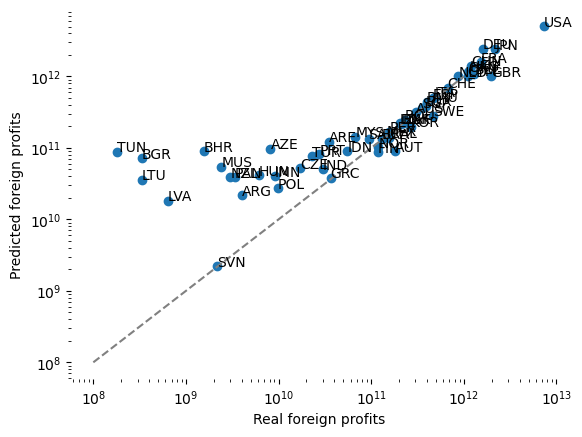

In [22]:
ground = true_values.loc[true_values["iso_parent"]=="NLD"]
for var in ['profit_loss_before_income_tax_corrected','n_employees',"unrelated_party_revenues","tangible_assets_except_cash",'stated_capital','total_revenues','related_party_revenues','holding_or_managing_ip']:
    ground["ln_"+var] = np.log(1+ground[var])
  
print("Predictions for NLDs")
display(ground)
display(np.exp(cbcr_with_imputed_domestic_values.loc[cbcr_with_imputed_domestic_values["iso_parent"]=="NLD",
                                                     ['fitted_ln_profit_loss_before_income_tax_corrected','fitted_ln_n_employees',
                                                      "fitted_ln_unrelated_party_revenues","fitted_ln_tangible_assets_except_cash",
                                                      'ln_profit_loss_before_income_tax_corrected','ln_n_employees',
                                                      "ln_unrelated_party_revenues","ln_tangible_assets_except_cash"]]))
foreign_nl = cbcr_with_imputed_foreign_values.loc[cbcr_with_imputed_foreign_values["iso_parent"]=="NLD",
                                                    ['fitted_ln_profit_loss_before_income_tax_corrected','fitted_ln_n_employees',
                                                      "fitted_ln_unrelated_party_revenues","fitted_ln_tangible_assets_except_cash"]]
display(np.exp(foreign_nl).sum().T)

plot_matching_foreign(true_values,cbcr_with_imputed_foreign_values, annot=True)

### 3.5 Generate bootstrapped sample with imputed values

In [23]:
def one_boot():
    '''Fit the modelRequires as global variables:    - df_domestic    - df_foreign    - df_fin_mis    - df_dom_remaining'''
    ## DOMESTIC: Impute domestic data and fit model
    variables_used_for_domestic_imputation = np.array(domestic_imputation_sample.columns)[domestic_imputation_sample.dtypes!=object]
    variables_used_for_domestic_imputation = [_ for _ in variables_used_for_domestic_imputation if (_ not in true_values.columns) and (_[3:] not in true_values.columns)]

    imputation_domestic = impute(domestic_imputation_sample,variables_used_for_domestic_imputation)
    cbcr_domestic_filled = fill_domestic(imputation_domestic,bootstrap=True,output=True)

    ## FOREIGN: 
    # Impute foreign data and fit model
    cbcr_foreign_filled = fill_foreign(foreign_imputation_sample,bootstrap=True,output=False)

    
    # Correct the information that we know from the raw data
    for var in ['ln_profit_loss_before_income_tax_corrected','ln_n_employees',"ln_unrelated_party_revenues","ln_tangible_assets_except_cash",
        'ln_stated_capital','ln_total_revenues','ln_related_party_revenues','ln_holding_or_managing_ip']:
                     #cbcr_foreign_filled[var+'imputed'] = 1
                    # cbcr_domestic_filled[var+'imputed'] = 1
                     cbcr_foreign_filled.loc[~np.isnan(cbcr_foreign_filled[var]),"fitted_"+var] = cbcr_foreign_filled.loc[~np.isnan(cbcr_foreign_filled[var]),var]
                     #cbcr_foreign_filled.loc[~np.isnan(cbcr_foreign_filled[var]), var+'imputed'] = 0
                     cbcr_domestic_filled.loc[~np.isnan(cbcr_domestic_filled[var]),"fitted_"+var] = cbcr_domestic_filled.loc[~np.isnan(cbcr_domestic_filled[var]),var] 
                     #cbcr_domestic_filled.loc[~np.isnan(cbcr_domestic_filled[var]), var+'imputed'] = 0

    #countries with no companies have no profits/etc
    cbcr_domestic_filled.loc[(cbcr_domestic_filled["ln_n_companies_orbis"]==0),"fitted_"+var] = 0
    cbcr_foreign_filled.loc[cbcr_foreign_filled["ln_n_companies_orbis"]==0,"fitted_"+var] = 0

    # Placeholder for the results
    all_data = []
    
    # Loop through each iso_parent group
    for group, group_data in cbcr_foreign_filled.groupby("iso_parent"):
        # Adjust totals year by year for each iso_parent
        for year in range(first_year, first_year + n_years):
            yearly_data = adjust_total(group, group_data, year)
            all_data.append(yearly_data)

    cbcr_foreign_filled = pd.concat(all_data)

    ## CREATE DATASET
    # Calculate the numbers from the logs
    for var in ['ln_profit_loss_before_income_tax_corrected','ln_n_employees',"ln_unrelated_party_revenues","ln_tangible_assets_except_cash",
        'ln_stated_capital','ln_total_revenues','ln_related_party_revenues','ln_holding_or_managing_ip']:
        cbcr_foreign_filled.loc[:,var[3:]] = np.exp(cbcr_foreign_filled["fitted_"+var])-1
        cbcr_domestic_filled.loc[:,var[3:]] = np.exp(cbcr_domestic_filled["fitted_"+var])-1

    # Use only the domestic data of the countries we have no information
    cbcr_domestic_remaining = cbcr_domestic_filled.loc[~cbcr_domestic_filled["iso_parent"].isin(true_values["iso_parent"].unique())]

    # Merge the domestic data to the raw data
    cbcr_main = pd.concat([true_values,cbcr_domestic_remaining],sort=False)
    
    # Specify which raws correspond to domestic data
    cbcr_main["Domestic"] = (cbcr_main["iso_parent"]==cbcr_main["iso_partner"]).astype(int)

    
    ## ADJUST DATASET
    # Calculate the sum by destination country in the raw data
    cbcr_main_withsum = cbcr_main.copy()
    for var in ['n_employees',"unrelated_party_revenues","tangible_assets_except_cash",
        	'stated_capital','total_revenues','related_party_revenues','holding_or_managing_ip']:
        cbcr_main_withsum[f"raw_{var}_sum"] = cbcr_main_withsum.groupby(["iso_partner","Domestic"])[var].transform(np.sum)
        cbcr_main_withsum[f"{var}_pred"] = cbcr_main_withsum[f"{var}"].copy()
    
    # Calculate the sum by destination country in the predicted data
    predicted_values = cbcr_foreign_filled.groupby("iso_partner")[['n_employees',"unrelated_party_revenues","tangible_assets_except_cash",
        'stated_capital','total_revenues','related_party_revenues','holding_or_managing_ip']].sum()
    predicted_values.columns = ["n_employees_pred_sum","unrelated_party_revenues_pred_sum","tangible_assets_except_cash_pred_sum",
        'stated_capital_pred_sum','total_revenues_pred_sum','related_party_revenues_pred_sum','holding_or_managing_ip_pred_sum']
    
    # Merge both to adjust
    predicted_values = pd.merge(cbcr_main_withsum,predicted_values.reset_index(),how="outer")   
    
    # Calculate the ratio between predicted and raw, and keep the lowest of the two values
    predicted_values["extra_n_employees"] = (predicted_values["n_employees_pred_sum"]+1)/(predicted_values["raw_n_employees_sum"]+1).round(2)
    predicted_values["extra_unrelated_party_revenues"] = (predicted_values["unrelated_party_revenues_pred_sum"]+1)/(predicted_values["raw_unrelated_party_revenues_sum"]+1).round(2)
    predicted_values["extra_tangible_assets_except_cash"] = (predicted_values["tangible_assets_except_cash_pred_sum"]+1)/(predicted_values["raw_tangible_assets_except_cash_sum"]+1).round(2)
    predicted_values["extra_stated_capital"] = (predicted_values["stated_capital_pred_sum"]+1)/(predicted_values["raw_stated_capital_sum"]+1).round(2)
    predicted_values["extra_total_revenues"] = (predicted_values["total_revenues_pred_sum"]+1)/(predicted_values["raw_total_revenues_sum"]+1).round(2)
    predicted_values["extra_related_party_revenues"] = (predicted_values["related_party_revenues_pred_sum"]+1)/(predicted_values["raw_related_party_revenues_sum"]+1).round(2)
    predicted_values["extra_holding_or_managing_ip"] = (predicted_values["holding_or_managing_ip_pred_sum"]+1)/(predicted_values["raw_holding_or_managing_ip_sum"]+1).round(2)
    predicted_values["one"] = 1
    predicted_values["extra_top"] = predicted_values[["one","extra_n_employees","extra_unrelated_party_revenues","extra_tangible_assets_except_cash",
        "extra_stated_capital","extra_total_revenues","extra_related_party_revenues","extra_holding_or_managing_ip"]].max(1)
    predicted_values["extra_max"] = predicted_values[["extra_n_employees","extra_unrelated_party_revenues","extra_tangible_assets_except_cash",
        "extra_stated_capital","extra_total_revenues","extra_related_party_revenues","extra_holding_or_managing_ip"]].max(1)    
    predicted_values["extra"] = predicted_values[["extra_n_employees","extra_unrelated_party_revenues","extra_tangible_assets_except_cash",
        "extra_stated_capital","extra_total_revenues","extra_related_party_revenues","extra_holding_or_managing_ip"]].min(1)
    # If max is <1 don't adjust
    predicted_values.loc[predicted_values['extra_top']==1,"extra"] = predicted_values.loc[predicted_values['extra_top']==1,"extra_max"]
    # If max is >1 and min <1
    predicted_values.loc[(predicted_values['extra_max']>1)&(predicted_values['extra']<1),"extra"] = 1
    # Cap the adjustment to 10
    predicted_values.loc[predicted_values["extra"]>10,"extra"] = 10 #np.nan#Capped at 10 times 10# np.nan #Will remove that observation (during the correction step) when we are not capturing almost anything in the data
    # Don't adjust domestic data    
    predicted_values.loc[predicted_values["Domestic"]==1,"extra"] = 1
    
    # Perform adjustment
    predicted_values["profit_loss_before_income_tax_corrected"] = predicted_values["profit_loss_before_income_tax_corrected"]*predicted_values["extra"]
    for var in ['n_employees',"unrelated_party_revenues","tangible_assets_except_cash",'stated_capital','total_revenues','related_party_revenues','holding_or_managing_ip']:
        predicted_values[f"{var}_pred"] *= predicted_values["extra"]
    
    # Return data
    return predicted_values[["iso_partner","iso_parent","year","Domestic","income_tax_paid_on_cash_basis","n_employees_pred","unrelated_party_revenues_pred","tangible_assets_except_cash_pred",
    "profit_loss_before_income_tax_corrected","extra","n_employees","unrelated_party_revenues","tangible_assets_except_cash","profit_loss_before_income_tax_corrected",
    'stated_capital','total_revenues','related_party_revenues','holding_or_managing_ip']]

In [24]:
# Generate bootstrapped sample, (bootstrapping specified in "range")
with np.errstate(divide='ignore', invalid='ignore'), open(f'{data_intermediate}/cbcr_bootstrapped_imputation.csv',"w+") as f:
    for i in range(10):
        print(i+1, end=": ")
        pred = one_boot()
        pred["n_rep"] = i
        pred.to_csv(f,sep="\t",index = None,header = i==0)

1: (390, 10)
(390, 10)
ln_profit_loss_before_income_tax_corrected 0.2641070427481751
ln_n_employees 0.9319132709887357
ln_unrelated_party_revenues 0.9036990136478503
ln_tangible_assets_except_cash 0.7945464342644805
ln_stated_capital 0.780301284026027
ln_total_revenues 0.917318676561771
ln_related_party_revenues 0.6708786466885189
ln_holding_or_managing_ip 0.7301124879023333


c:\Users\AlisonSchultz\anaconda3\envs\sotj_profit_shifting_estimates\Lib\site-packages\sklearn\impute\_iterative.py:796: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient
Variable,,,,,,,,
ln_gdp_current_usd,2.211378,1.554960,1.398214,2.103174,3.203791,1.644324,1.818074,-0.113901
ln_population,1.265112,-0.417246,-0.256054,-0.913193,-1.633583,-0.604985,-0.489362,0.164055
ln_gvt_health_expenditure,-1.935215,-0.046215,-0.501107,-0.595220,-1.069754,-0.402725,-0.396592,0.309165
etr_foreign_corrected,-6.315969,0.354968,4.186902,2.224279,-1.203654,2.013493,-1.897149,1.224603
cit,8.986660,3.351398,-0.754005,-0.105328,2.514328,-0.114800,2.708096,-1.323461
ln_n_companies_orbis,2.663305,0.066187,0.379101,0.665302,0.447972,0.515766,-0.040295,-0.195965
ln_turnover_orbis,-2.356942,0.077617,0.120539,0.017666,0.254390,0.106276,0.413524,0.726489
ln_n_employees_orbis,0.441228,0.016906,0.127223,0.000415,-0.024711,0.034668,-0.037071,-0.032787
ln_wage_monthly,2.292878,-0.526526,0.065542,-0.843178,-0.940757,-0.319378,-0.064585,0.353909


dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_in

c:\Users\AlisonSchultz\anaconda3\envs\sotj_profit_shifting_estimates\Lib\site-packages\sklearn\impute\_iterative.py:796: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


...

,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient
Variable,,,,,,,,
ln_gdp_current_usd,0.234825,1.236276,1.128934,2.298628,2.556585,1.475725,2.737506,0.435975
ln_population,1.993335,-0.159797,-0.115885,-0.603898,-0.958442,-0.400607,-0.663022,-0.503486
ln_gvt_health_expenditure,-0.383094,-0.049136,-0.377348,-0.793914,-1.179645,-0.299702,-0.832386,0.669024
etr_foreign_corrected,11.702982,1.031485,3.627817,0.486741,0.493954,0.853969,-2.177028,-0.389964
cit,-13.041561,2.285685,-0.617550,1.246167,1.401523,1.314275,4.273568,-2.954092
ln_n_companies_orbis,1.752042,0.224246,0.380390,0.322445,-0.136838,0.358767,-0.364133,-0.083058
ln_turnover_orbis,-1.896567,-0.072798,0.176232,0.061953,0.648639,0.114780,0.372045,0.608520
ln_n_employees_orbis,0.577662,0.098324,0.050841,-0.014008,0.174419,0.037754,-0.049056,-0.083222
ln_wage_monthly,2.379989,-0.325828,0.102844,-0.323624,-0.571914,-0.130425,0.108959,-0.339817


dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_in

c:\Users\AlisonSchultz\anaconda3\envs\sotj_profit_shifting_estimates\Lib\site-packages\sklearn\impute\_iterative.py:796: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient,Coefficient
Variable,,,,,,,,
ln_gdp_current_usd,4.679829,1.645628,1.174091,1.911857,3.277278,1.564480,3.184433,0.326406
ln_population,-0.556214,-0.160709,-0.243870,-0.666349,-1.707783,-0.466652,-1.351472,-0.290665
ln_gvt_health_expenditure,-2.054925,-0.314645,-0.215861,-0.638426,-1.003055,-0.475636,-0.915263,0.393930
etr_foreign_corrected,3.623656,1.058690,3.065036,1.798761,-1.489418,2.131726,0.231798,1.025961
cit,-5.642499,2.434542,-0.721763,0.164738,1.702016,1.473678,2.287389,-0.867690
ln_n_companies_orbis,-0.486219,0.334857,0.882779,0.547198,-0.124590,0.210370,-0.127454,-0.106142
ln_turnover_orbis,-0.401579,-0.315631,-0.229689,0.021154,0.590773,0.299688,0.466405,0.649024
ln_n_employees_orbis,0.601267,0.184847,0.083416,0.018556,0.049147,0.033713,-0.045672,-0.054270
ln_wage_monthly,0.559357,-0.121341,-0.043882,-0.570023,-1.175003,-0.155826,-0.535094,-0.028685


dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_income_tax_corrected', 'ln_n_employees', 'ln_unrelated_party_revenues', 'ln_tangible_assets_except_cash', 'ln_stated_capital', 'ln_total_revenues', 'ln_related_party_revenues', 'ln_holding_or_managing_ip'])
dict_keys(['ln_profit_loss_before_in

### Combine imputed data with other data

In [25]:
def num(x):
    """
    Convert numbers of strings to floats
    """
    try:
        return float(x)
    except:
        return np.nan

In [26]:
cbcr_with_imputeded_data = pd.read_csv(f'{data_intermediate}cbcr_bootstrapped_imputation.csv',sep="\t").reset_index(drop=True)

#cbcr_main = cbcr_main.drop_duplicates()
for col in list(cbcr_with_imputeded_data.columns)[2:]:
    cbcr_with_imputeded_data[col] = cbcr_with_imputeded_data[col].apply(num)
    
#cbcr_main = cbcr_main.dropna()
columns_from_original_data = ['iso_parent','iso_partner','year',
            'wage_monthly','gdp_current_usd','gvt_health_expenditure',
            'cit','etr_foreign_corrected','population', 'etr_domestic_corrected', 'etr_average_corrected',
            'region_tjn', 'ukt']
cbcr_with_imputeded_data = cbcr_with_imputeded_data.merge(cbcr_main_no_imputation_allsubgroupsonly[columns_from_original_data],
            on=['iso_partner', 'year'], how='outer')
cbcr_with_imputeded_data['payroll'] = cbcr_with_imputeded_data['n_employees'] * cbcr_with_imputeded_data['wage_monthly'] * 12 
cbcr_with_imputeded_data.to_csv(f'{data_final}/cbcr_with_imputed_data.csv')